In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv(".//CSV//titanic.csv")
df.shape

(891, 12)

In [2]:
numerical_df = df.select_dtypes(
    include=['int64','float64']
)

numerical_df.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500


In [3]:
corr_matrix = numerical_df.corr()

corr_matrix

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


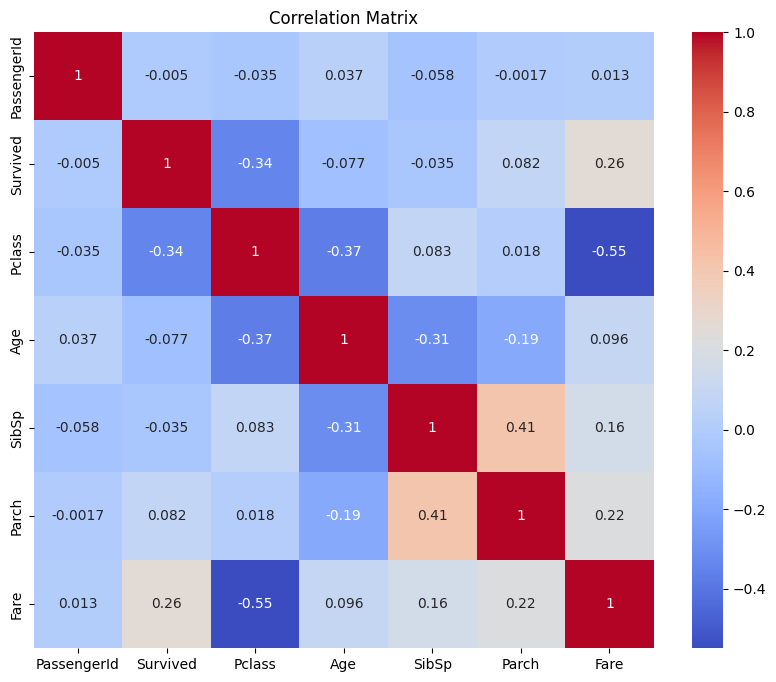

In [4]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

In [12]:
target = "Survived"

corr_with_target = (
    corr_matrix[target]
    .sort_values(ascending=False)
)

corr_with_target

Survived       1.000000
Fare           0.257307
Parch          0.081629
PassengerId   -0.005007
SibSp         -0.035322
Age           -0.077221
Pclass        -0.338481
Name: Survived, dtype: float64

In [10]:
def target_correlation(df, target):

    numerical_df = df.select_dtypes(
        include=['int64', 'float64']
    )

    corr_matrix = numerical_df.corr()

    corr_target = (
        corr_matrix[target]
        .drop(target)
        .sort_values(
            ascending=False
        )
    )

    return corr_target

In [11]:
target_correlation(
    df,
    "Survived"
)

Fare           0.257307
Parch          0.081629
PassengerId   -0.005007
SibSp         -0.035322
Age           -0.077221
Pclass        -0.338481
Name: Survived, dtype: float64

In [13]:
def find_strong_correlations(
    df,
    threshold=0.5
):

    corr_matrix = (
        df.select_dtypes(
            include=['int64','float64']
        )
        .corr()
    )

    correlations = []

    cols = corr_matrix.columns

    for i in range(len(cols)):

        for j in range(i+1, len(cols)):

            corr = corr_matrix.iloc[
                i,
                j
            ]

            if abs(corr) >= threshold:

                correlations.append({
                    "Feature1": cols[i],
                    "Feature2": cols[j],
                    "Correlation": round(
                        corr,
                        2
                    )
                })

    return pd.DataFrame(
        correlations
    )

In [14]:
strong_correlations(df)

,Feature1,Feature2,Correlation
0,Pclass,Fare,-0.55
1,Fare,Pclass,-0.55
